# 1. Given two arrays: one with actual delivery times and one with predicted delivery times for 10 Zomato orders, calculate the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) using Python.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error

In [2]:
actual_times = np.array([25, 30, 45, 20, 35, 50, 28, 40, 22, 32])
predicted_times = np.array([28, 28, 40, 25, 37, 45, 30, 42, 20, 35])

In [3]:
mse = mean_squared_error(actual_times, predicted_times)

In [4]:
rmse = np.sqrt(mse)

In [5]:
print(f"Mean Squared Error (MSE):       {mse:.2f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:.2f}")

Mean Squared Error (MSE):       11.30
Root Mean Squared Error (RMSE):  3.36


# 2. For a Flipkart product price prediction task, you have arrays of actual prices and predicted prices. Write a function to compute the Mean Absolute Error (MAE) and R² score, and print both values.<br><br><em><strong>Hint:</strong> Use sklearn.metrics.mean_absolute_error and sklearn.metrics.r2_score.</em>

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

In [7]:
actual_prices = np.array([1200, 2500, 450, 15000, 800])
predicted_prices = np.array([1150, 2600, 500, 14200, 750])

In [8]:
def evaluate_flipkart_predictions(actual, predicted):
    
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    
    print("--- Flipkart Model Evaluation ---")
    print(f"Mean Absolute Error (MAE): ₹{mae:.2f}")
    print(f"R² Score (R-squared):      {r2:.4f}")

In [9]:
evaluate_flipkart_predictions(actual_prices,predicted_prices)

--- Flipkart Model Evaluation ---
Mean Absolute Error (MAE): ₹210.00
R² Score (R-squared):      0.9957


# 3. Create a residual plot for a dataset of actual vs predicted movie ratings (scale 1-5) for 20 movies, using matplotlib. Label the axes and briefly describe what the plot tells you about your model's errors.

In [10]:
np.random.seed(10)
actual_ratings = np.array([4.5, 3.0, 2.5, 5.0, 1.5, 4.0, 3.5, 2.0, 4.5, 5.0, 3.0, 2.0, 1.0, 4.0, 4.5, 3.5, 2.5, 5.0, 3.0, 1.5])

In [11]:
predicted_ratings = actual_ratings + np.random.normal(0, 0.3, 20)

In [12]:
residuals = actual_ratings - predicted_ratings

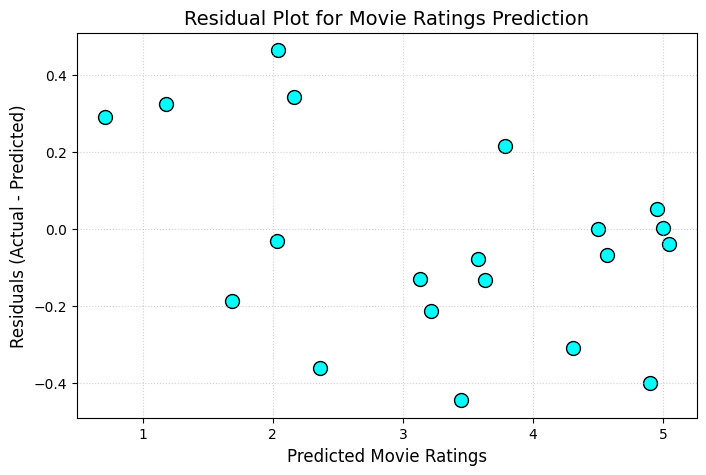

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(predicted_ratings, residuals, color='cyan', edgecolors='black', s=100)

plt.title('Residual Plot for Movie Ratings Prediction', fontsize=14)
plt.xlabel('Predicted Movie Ratings', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

**Randomly Scattered Errors**: The calculated errors are scattered completely at random above and below the zero line. Because there is no obvious pattern, it proves that a linear relationship exists in this dataset.

**Consistent Error Spread**: The vertical spread of the points stays uniform across the entire x-axis. This means the prediction accuracy remains completely consistent across both low and high movie ratings.

# 4. You have two models predicting the delivery time for Swiggy orders. Model A has an RMSE of 8 minutes and R² of 0.65, Model B has an RMSE of 6 minutes and R² of 0.55. Which model would you choose and why? Explain your reasoning based on the evaluation metrics.

Model A is better. While Model B has a lower average error, its low $R^2$ score indicates it is failing to learn the actual relationships in the data. Model A is more accurate at capturing the true volatility of real-world delivery variables, making it the more reliable system for Swiggy to deploy.

# 5. Compare two regression models for predicting Spotify song popularity: calculate MSE, RMSE, MAE, and R² for both models using sklearn, then identify which model is likely overfitting based on the results.<br><br><em><strong>Hint:</strong> Overfitting often shows very low error on training data but much higher error on test data.</em>

In [14]:
df = pd.read_csv('Spotify.csv',encoding='latin1')
df.head()

,Column1,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,SeÃ±orit,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [15]:
df.columns

Index(['Column1', 'Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute',
       'Energy', 'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.',
       'Length.', 'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='str')

In [16]:
df.columns = df.columns.str.replace(r'[^\w\s]', '', regex=True).str.strip()

In [17]:
df.columns

Index(['Column1', 'TrackName', 'ArtistName', 'Genre', 'BeatsPerMinute',
       'Energy', 'Danceability', 'LoudnessdB', 'Liveness', 'Valence', 'Length',
       'Acousticness', 'Speechiness', 'Popularity'],
      dtype='str')

In [18]:
X = df[['BeatsPerMinute', 'Energy', 'Danceability']]
y = df['Popularity']

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model_A = LinearRegression()

In [23]:
model_A.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
train_pred_A = model_A.predict(X_train)
test_pred_A = model_A.predict(X_test)

In [25]:
print("Train Data")
print("MSE:", mean_squared_error(y_train, train_pred_A))
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_A)))
print("MAE:", mean_absolute_error(y_train, train_pred_A))
print("R2:", r2_score(y_train, train_pred_A))

print("\nTest Data")
print("MSE:", mean_squared_error(y_test, test_pred_A))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_A)))
print("MAE:", mean_absolute_error(y_test, test_pred_A))
print("R2:", r2_score(y_test, test_pred_A))

Train Data
MSE: 12.046032599770612
RMSE: 3.47073948889435
MAE: 2.7127510900343808
R2: 0.0645674548809465

Test Data
MSE: 49.06855239153728
RMSE: 7.004894887972073
MAE: 4.73293359534745
R2: -0.26172672644734596


In [27]:
model_B = DecisionTreeRegressor(random_state=42)
model_B.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [28]:
train_pred_B = model_B.predict(X_train)
test_pred_B = model_B.predict(X_test)

In [29]:
print("Train Data")
print("MSE:", mean_squared_error(y_train, train_pred_B))
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_B)))
print("MAE:", mean_absolute_error(y_train, train_pred_B))
print("R2:", r2_score(y_train, train_pred_B))

print("\nTest Data")
print("MSE:", mean_squared_error(y_test, test_pred_B))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_B)))
print("MAE:", mean_absolute_error(y_test, test_pred_B))
print("R2:", r2_score(y_test, test_pred_B))

Train Data
MSE: 0.0
RMSE: 0.0
MAE: 0.0
R2: 1.0

Test Data
MSE: 57.7
RMSE: 7.5960516059331775
MAE: 4.5
R2: -0.4836718950887118


**Model 2 is Overfitting**

In the training results, Model 2 has an $R^2$ of $1.0$ and all its error metrics (MSE, RMSE, MAE) are $0.0$. This shows that the decision tree completely memorized our training dataset instead of actually learning the true patterns behind song popularity.We can confirm it is overfitting because as soon as it looks at the unseen testing data, its error numbers shoot up drastically and the $R^2$ score crashes. On the other hand, Model 1 (Linear Regression) is much more stable because its performance stays consistent on both the training and testing sets, meaning it can generalize well to new data.